# 🧬 Bioinformatics × Deep Learning: From Cell Nuclei to Neural Networks
### *A Software Engineer's Field Guide to Structural AI in Medicine*

---

## Welcome: What You Are About to Build

This notebook is a **bridge**. You already understand systems — data flows, state machines, APIs, typed interfaces. What you are about to discover is that **biology is also a system** — just one that evolved over 3.8 billion years instead of being written in a sprint.

We are going to:
1. Load real cellular geometry data from breast cancer biopsies
2. Treat each cell nucleus like a **struct** full of float features
3. Build a neural network that learns a **decision boundary** separating malignant from benign tissue
4. Do all of it at the mathematical metal — no shortcuts, no black boxes

---

## The Biological Problem We Are Solving

When a pathologist examines a breast tissue biopsy, they are looking at individual cell nuclei under a microscope. Healthy cells have **regular, uniform nuclei** — smooth borders, consistent size. Cancerous cells, undergoing chaotic uncontrolled replication, have **irregular, jagged, enlarged nuclei** — broken geometry.

The UCI Breast Cancer Wisconsin (Diagnostic) dataset digitizes this visual judgment. A computer vision system measured **30 geometric features** from cell nucleus images: radius, texture, perimeter, area, smoothness, compactness, concavity, and more — each measured as mean, worst-case, and standard error across the nuclei in a sample.

Our job: **teach a neural network to read this geometry and classify the tissue.**

---

## Why This Is a Perfect Problem for a Software Engineer

Think of each patient's cell sample as a **JSON object** with 30 float fields. The neural network is a **function** that maps this object to a probability: `P(malignant | cell_geometry)`. Training is **iterative optimization** — like gradient-descent-powered parameter tuning. Backpropagation is just the **chain rule of calculus** applied to a computation graph — not unlike how a compiler traces dependency trees.

The math is real. The biology is real. Let's begin.


---
# Cell 1: Environment Setup & Cloud Persistence

## 🔬 Why This Cell Exists

### The Cloud Notebook Problem
Google Colab and similar platforms run on **ephemeral virtual machines**. After ~90 minutes of idle time, the VM is recycled — your local filesystem disappears. Any model weights you trained, any processed data you cached, any plots you saved: gone.

This is exactly like running a **stateless serverless function** — it spins up, does work, and dies. The fix is the same as in distributed systems: **externalize state to persistent storage**. Google Drive is our S3 bucket.

### What We Are Installing
- **PyTorch**: The deep learning framework. Gives us automatic differentiation (`autograd`), GPU tensors, and `nn.Module` — the base class for every neural network layer.
- **NumPy**: Numerical Python. Our raw matrix math library — think of it as a vectorized, hardware-optimized version of operating on 2D arrays.
- **Pandas**: Structured data manipulation. DataFrames are like typed database tables in memory.
- **Matplotlib/Seaborn**: Visualization. We will use these to plot loss curves and feature distributions.
- **scikit-learn**: Only for dataset loading and train/test splitting — NOT for the neural network itself.

### The `seed` Discipline
Neural networks are **initialized with random weights**. Without a fixed random seed, every run produces different results — making debugging and reproducibility impossible. Setting `torch.manual_seed(42)` and `np.random.seed(42)` pins the random number generators to a deterministic state. This is the equivalent of setting `Math.random` to a fixed sequence — professional ML code always does this.


In [4]:
# ============================================================
# CELL 1: ENVIRONMENT SETUP & CLOUD PERSISTENCE
# ============================================================

# --- Step 1: Install Dependencies ---
# The -q flag suppresses verbose pip output ("quiet" mode).
# In a production notebook, you want clean output — not 200 lines of
# dependency resolution logs.
!pip install -q torch torchvision numpy pandas matplotlib seaborn scikit-learn

# --- Step 2: Google Drive Mount (Defensive) ---
# We wrap this in a try/except because:
# 1. You might be running this locally (not in Colab) — mounting fails gracefully
# 2. Drive might already be mounted — re-mounting throws an error
# This is the same "check before act" pattern you use with idempotent API calls.
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_PATH = '/content/drive/MyDrive/BioInformatics_DL/'
    import os
    os.makedirs(DRIVE_PATH, exist_ok=True)
    print(f"✅ Google Drive mounted. Persistent storage at: {DRIVE_PATH}")
    print("   → Model checkpoints and processed data will survive container restarts.")
except ImportError:
    # Running locally — use a local directory instead
    import os
    DRIVE_PATH = 'breast_cancer_output/'
    os.makedirs(DRIVE_PATH, exist_ok=True)
    print(f"📁 Local mode detected. Output path: {DRIVE_PATH}")

# --- Step 3: Core Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')  # Suppress sklearn deprecation warnings

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Only using sklearn for dataset loading and splitting — not for the model
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# --- Step 4: Deterministic Seeds ---
# Pins random number generators so results are reproducible across runs.
# Think of this as setting a fixed random seed in a game engine or simulation.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Detect hardware: GPU (CUDA) > Apple Silicon (MPS) > CPU
# In production, you'd never hardcode 'cpu' — let PyTorch find the best device.
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f"\n🔧 Environment Summary")
print(f"   PyTorch version : {torch.__version__}")
print(f"   NumPy version   : {np.__version__}")
print(f"   Compute device  : {DEVICE}")
print(f"   Random seed     : {SEED}")
print(f"\n✅ Environment ready. Proceeding to biological data analysis.")


Mounted at /content/drive
✅ Google Drive mounted. Persistent storage at: /content/drive/MyDrive/BioInformatics_DL/
   → Model checkpoints and processed data will survive container restarts.

🔧 Environment Summary
   PyTorch version : 2.11.0+cpu
   NumPy version   : 2.0.2
   Compute device  : cpu
   Random seed     : 42

✅ Environment ready. Proceeding to biological data analysis.


---
# Cell 2: Exploratory Data Analysis & Biological Geometry

## 🔬 The Biology: Why Cancer Changes Cell Shape

Normal cells divide in a **tightly regulated cycle** — controlled by proteins called cyclins and tumor suppressors like p53. When these regulatory genes mutate, cells lose their division checkpoints and replicate uncontrollably. This chaos manifests **geometrically**:

| Geometric Feature | Healthy Cell | Cancerous Cell | Why |
|---|---|---|---|
| **Radius** | Small, uniform | Large, variable | Rapid growth stretches the nucleus |
| **Texture** (std dev of gray values) | Smooth | Rough/grainy | Chromatin reorganizes chaotically |
| **Perimeter** | Smooth circle | Jagged, irregular | Cell membrane loses cytoskeletal control |
| **Smoothness** | High | Low | Irregular replication breaks surface regularity |
| **Concavity** | Near zero | High | Nuclear membrane caves inward from internal pressure |
| **Symmetry** | High | Low | Asymmetric chromosome segregation |

This is the key biological insight: **geometry is information**. A pathologist reads shape. Our neural network will learn to do the same.

## 📐 The Mathematics: What EDA Actually Is

Exploratory Data Analysis is not just "looking at the data." It is **computing the statistical geometry of your feature space**:

- **Mean** (`μ`): The centroid of each feature dimension. If malignant mean radius >> benign mean radius, the two classes are **linearly separable** on that axis — good for our network.
- **Standard Deviation** (`σ`): The spread around the centroid. High σ means features overlap heavily between classes — harder to classify.
- **Variance** (`σ²`): σ squared. Used in normalization formulas (Z-score uses σ, not σ²).

Before writing a single neural network line, a good ML engineer asks:
> *"Are my classes actually separable in feature space? Which features carry the most discriminative signal?"*

## 🧮 The Dataset Structure

- **569 samples** (patients' cell samples)
- **30 features** per sample (geometric measurements of nuclei)
- **2 classes**: Malignant (1) and Benign (0)
- **Class distribution**: ~37% Malignant, ~63% Benign — mild imbalance, acceptable for BCELoss


 BREAST CANCER WISCONSIN DIAGNOSTIC DATASET — STRUCTURE
Total samples     : 569
Feature dimensions: 30  (30 geometric nuclear features)
Malignant samples : 212 (37.3%)
Benign samples    : 357 (62.7%)

 BIOLOGICAL FEATURE STATISTICS: MALIGNANT vs. BENIGN
          Feature Malign Mean Malign Std Benign Mean Benign Std   Δ Mean Discriminative
           Radius     17.4628     3.1964     12.1465     1.7780   5.3163         🔴 HIGH
          Texture     21.6049     3.7705     17.9148     3.9895   3.6901          🟡 MOD
        Perimeter    115.3654    21.8030     78.0754    11.7909  37.2900         🔴 HIGH
             Area    978.3764   367.0692    462.7902   134.0989 515.5862         🔴 HIGH
       Smoothness      0.1029     0.0126      0.0925     0.0134   0.0104          🟡 MOD
      Compactness      0.1452     0.0539      0.0801     0.0337   0.0651         🔴 HIGH
        Concavity      0.1608     0.0748      0.0461     0.0434   0.1147         🔴 HIGH
   Concave Points      0.0880     0.0343  

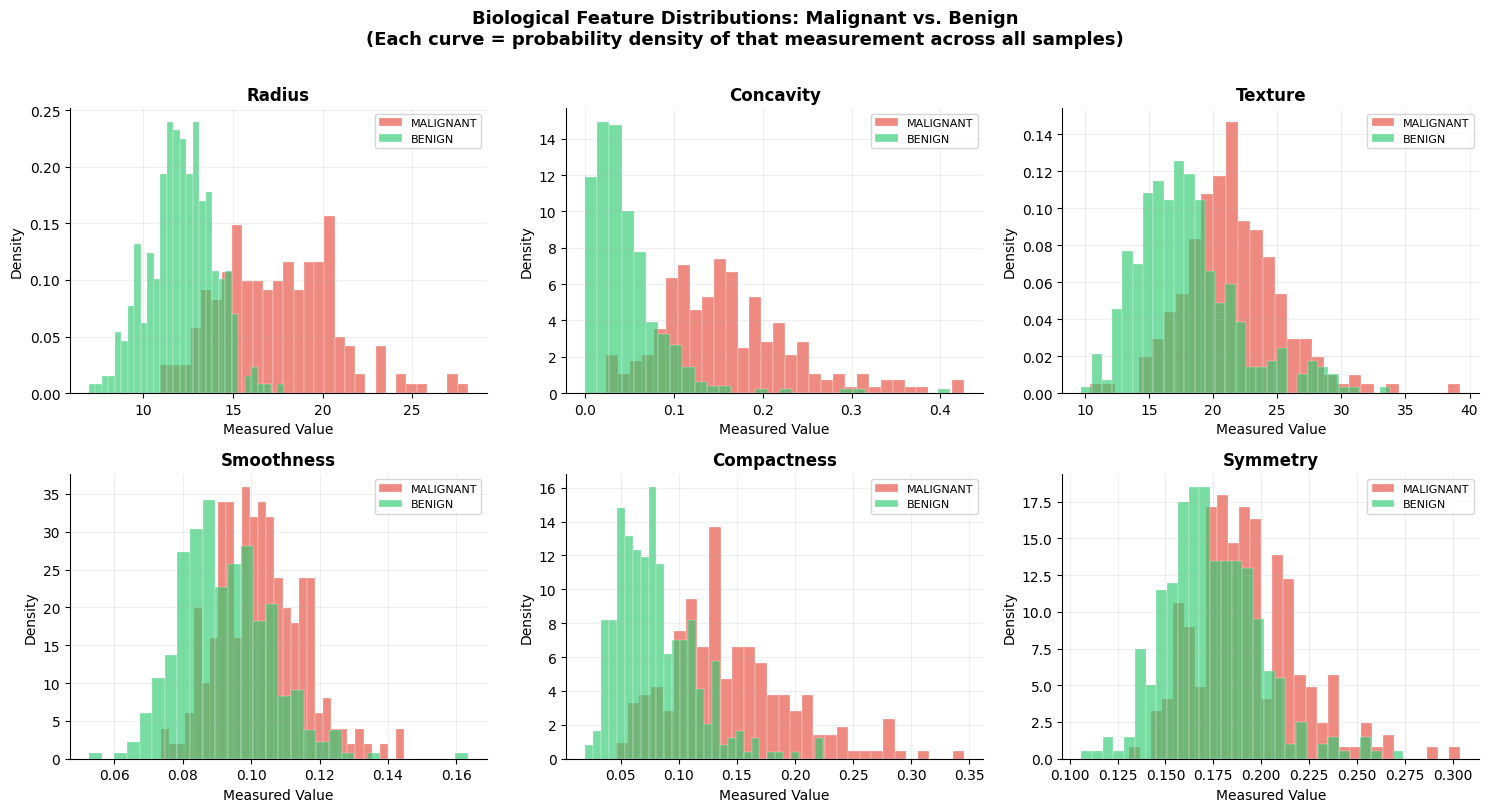


📊 Distribution plot saved to persistent storage.


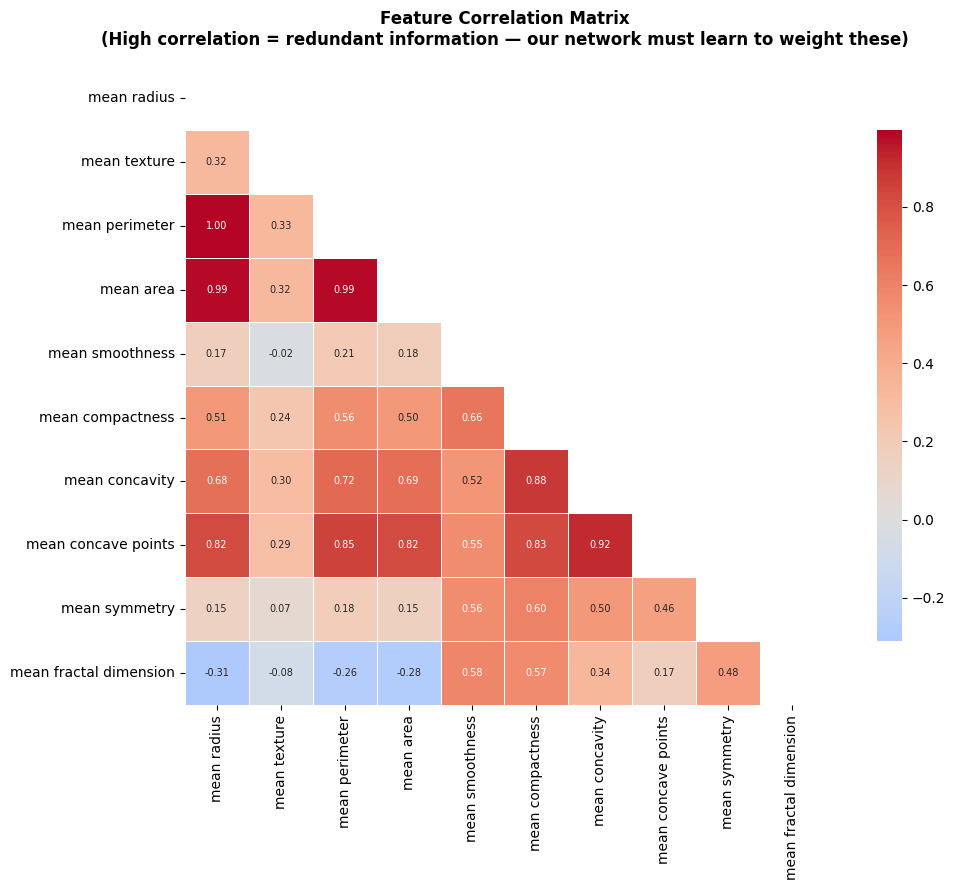

📊 Correlation heatmap saved.

💡 Notice: radius, perimeter, and area are HIGHLY correlated (r > 0.9).
   This makes sense — they all describe nucleus SIZE geometrically.
   Our network will learn to handle this redundancy via weight sharing.


In [5]:
# ============================================================
# CELL 2: EXPLORATORY DATA ANALYSIS & BIOLOGICAL GEOMETRY
# ============================================================

# --- Load Dataset ---
# sklearn.datasets wraps the UCI Breast Cancer Wisconsin dataset.
# It returns a Bunch object (like a typed dict): .data, .target, .feature_names
raw = load_breast_cancer()

# Convert to pandas DataFrame for readable EDA
# Shape: (569, 30) — 569 cell samples, 30 geometric features each
df = pd.DataFrame(raw.data, columns=raw.feature_names)
df['diagnosis'] = raw.target  # 0 = Malignant, 1 = Benign (sklearn uses 0/1)

# --- Remap labels to be intuitive ---
# sklearn encodes: 0 = malignant, 1 = benign
# We will use: 1 = malignant, 0 = benign (standard medical convention)
# This means our model output "high probability" = high malignancy risk
df['diagnosis'] = 1 - df['diagnosis']  # flip: 1 = malignant, 0 = benign
label_map = {1: 'MALIGNANT', 0: 'BENIGN'}

print("=" * 65)
print(" BREAST CANCER WISCONSIN DIAGNOSTIC DATASET — STRUCTURE")
print("=" * 65)
print(f"Total samples     : {df.shape[0]}")
print(f"Feature dimensions: {df.shape[1] - 1}  (30 geometric nuclear features)")
print(f"Malignant samples : {(df.diagnosis == 1).sum()} ({(df.diagnosis==1).mean()*100:.1f}%)")
print(f"Benign samples    : {(df.diagnosis == 0).sum()} ({(df.diagnosis==0).mean()*100:.1f}%)")

# --- Biological Feature Spotlight ---
# Select the 10 most biologically interpretable 'mean' features
bio_features = [
    'mean radius', 'mean texture', 'mean perimeter',
    'mean area', 'mean smoothness', 'mean compactness',
    'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension'
]

# --- Compute per-class statistics using raw NumPy (no sklearn) ---
# This is the educational core: doing statistics at the array level

malignant_data = df[df.diagnosis == 1][bio_features].values  # shape: (212, 10)
benign_data    = df[df.diagnosis == 0][bio_features].values  # shape: (357, 10)

# np.mean(axis=0): collapse rows → gives column-wise mean
# This is a matrix reduction: (N, 10) → (10,)
m_mean = np.mean(malignant_data, axis=0)
b_mean = np.mean(benign_data,    axis=0)
m_std  = np.std(malignant_data,  axis=0)
b_std  = np.std(benign_data,     axis=0)
m_var  = np.var(malignant_data,  axis=0)
b_var  = np.var(benign_data,     axis=0)

# Build a summary DataFrame for display
summary_rows = []
for i, feat in enumerate(bio_features):
    summary_rows.append({
        'Feature'       : feat.replace('mean ', '').title(),
        'Malign Mean'   : f"{m_mean[i]:.4f}",
        'Malign Std'    : f"{m_std[i]:.4f}",
        'Benign Mean'   : f"{b_mean[i]:.4f}",
        'Benign Std'    : f"{b_std[i]:.4f}",
        'Δ Mean'        : f"{abs(m_mean[i] - b_mean[i]):.4f}",
        'Discriminative': '🔴 HIGH' if abs(m_mean[i] - b_mean[i]) / (b_std[i] + 1e-8) > 1.0 else '🟡 MOD'
    })

summary_df = pd.DataFrame(summary_rows)

print("\n" + "=" * 65)
print(" BIOLOGICAL FEATURE STATISTICS: MALIGNANT vs. BENIGN")
print("=" * 65)
print(summary_df.to_string(index=False))

print("\n📌 KEY BIOLOGICAL OBSERVATIONS:")
print("   → Malignant nuclei have larger radius, perimeter, and area")
print("     (rapid replication stretches and enlarges the nucleus)")
print("   → Concavity is MUCH higher in malignant samples")
print("     (nuclear membrane caves inward from uneven internal pressure)")
print("   → Smoothness drops in malignant tissue")
print("     (irregular surface = loss of cytoskeletal control)")
print("   → These Δ Mean differences ARE the signal our network will learn.")

# --- Visualization: Feature Distribution by Class ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Biological Feature Distributions: Malignant vs. Benign\n(Each curve = probability density of that measurement across all samples)',
             fontsize=13, fontweight='bold', y=1.01)

highlight_features = ['mean radius', 'mean concavity', 'mean texture',
                       'mean smoothness', 'mean compactness', 'mean symmetry']
colors = {'MALIGNANT': '#e74c3c', 'BENIGN': '#2ecc71'}

for ax, feat in zip(axes.flat, highlight_features):
    for label_val, label_name in label_map.items():
        subset = df[df.diagnosis == label_val][feat].values
        ax.hist(subset, bins=30, alpha=0.65, color=colors[label_name],
                label=label_name, density=True, edgecolor='white', linewidth=0.3)
    ax.set_title(feat.replace('mean ', '').title(), fontweight='bold')
    ax.set_xlabel('Measured Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}01_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Distribution plot saved to persistent storage.")

# --- Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df[bio_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix\n(High correlation = redundant information — our network must learn to weight these)', 
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Correlation heatmap saved.")
print("\n💡 Notice: radius, perimeter, and area are HIGHLY correlated (r > 0.9).")
print("   This makes sense — they all describe nucleus SIZE geometrically.")
print("   Our network will learn to handle this redundancy via weight sharing.")


---
# Cell 3: PyTorch Data Pipeline — From Scratch

## 🔬 Why Biological Data Needs Normalization

Look at the raw feature values in Cell 2:
- `mean area` ranges from ~143 to ~2501
- `mean smoothness` ranges from ~0.05 to ~0.16

These are in completely different **units and scales** — area is in µm², smoothness is a dimensionless ratio. If we feed these raw values to a neural network, the features with large magnitudes (area) will **dominate the gradient signal**, while small-magnitude features (smoothness) will barely contribute.

The result: the network becomes biased toward large-scale features, even when small-scale features carry critical information.

## 📐 Z-Score Normalization: The Math

Z-score normalization (standardization) transforms each feature column `x` into:

$$z = \frac{x - \mu}{\sigma}$$

Where `μ` is the column mean and `σ` is the column standard deviation.

**After transformation:**
- Every feature has **mean = 0** and **standard deviation = 1**
- Features are now on a **common scale** — the gradient landscape is smooth and symmetric
- Gradient descent converges **much faster** and more reliably

**CRITICAL RULE**: Compute `μ` and `σ` ONLY on the **training set**, then apply the same transform to the test set. Never use test data statistics — that would be **data leakage**, like calibrating your scale using the weight you're trying to measure.

## 🏗️ The PyTorch Dataset Architecture

PyTorch uses a **contract-based data loading system**. You define a class that inherits from `torch.utils.data.Dataset` and implement exactly 3 methods:

| Method | Analogy | What it does |
|---|---|---|
| `__init__(self, ...)` | Constructor | Stores the data, runs preprocessing |
| `__len__(self)` | `array.length` | Returns total number of samples |
| `__getitem__(self, idx)` | `array[idx]` | Returns one (features, label) pair |

The `DataLoader` wraps your Dataset and handles **batching, shuffling, and parallel loading** — equivalent to a streaming cursor over a database with automatic pagination.

## 🧮 What Is a Tensor?

A **tensor** is a generalization of matrices to arbitrary dimensions:
- Scalar = 0D tensor (a single number)
- Vector = 1D tensor (shape: `[n]`)
- Matrix = 2D tensor (shape: `[rows, cols]`)
- Batch of feature vectors = 2D tensor (shape: `[batch_size, n_features]`)

PyTorch tensors look like NumPy arrays, but they live in a **computation graph** — every operation records itself so that gradients can be computed by calling `.backward()` later.


In [6]:
# ============================================================
# CELL 3: PYTORCH DATA PIPELINE — FROM SCRATCH
# ============================================================

# --- Step 1: Extract Raw Arrays ---
# raw.data shape: (569, 30) — all 30 features
# raw.target shape: (569,)  — 0 = malignant, 1 = benign (sklearn convention)
X = raw.data.astype(np.float64)      # Feature matrix: (569, 30)
y = (1 - raw.target).astype(np.float64)  # Flip: 1 = malignant, 0 = benign

print(f"Raw feature matrix shape : {X.shape}  → (n_samples, n_features)")
print(f"Raw label vector shape   : {y.shape}  → (n_samples,)")
print(f"Feature range BEFORE norm: [{X.min():.2f}, {X.max():.2f}]")
print(f"  (Notice: huge range! area up to {X[:, 3].max():.0f} vs smoothness at {X[:, 4].min():.4f})")

# --- Step 2: Train/Test Split ---
# 80% training, 20% testing. stratify=y ensures both splits have
# the same malignant/benign ratio — prevents accidentally skewed test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"\nTrain set : {X_train.shape[0]} samples")
print(f"Test set  : {X_test.shape[0]} samples")

# --- Step 3: Z-Score Normalization Using Raw NumPy ---
# RULE: fit on train ONLY, transform both train and test
# This mirrors how you'd compute stats from a training database query
# and apply those same stats to production inference inputs.

mu    = np.mean(X_train, axis=0)   # shape: (30,) — per-feature mean vector
sigma = np.std(X_train, axis=0)    # shape: (30,) — per-feature std vector

# NumPy broadcasting: (455, 30) - (30,) = (455, 30)
# Each row gets the SAME mu/sigma subtracted/divided column-wise
X_train_norm = (X_train - mu) / (sigma + 1e-8)  # 1e-8 prevents division by zero
X_test_norm  = (X_test  - mu) / (sigma + 1e-8)  # Use TRAIN stats on test!

print(f"\nAfter Z-score normalization:")
print(f"  Train feature range : [{X_train_norm.min():.4f}, {X_train_norm.max():.4f}]")
print(f"  Train feature mean  : {X_train_norm.mean():.6f}  (should be ~0.0)")
print(f"  Train feature std   : {X_train_norm.std():.6f}   (should be ~1.0)")
print(f"  → All 30 features now live on the same scale. Gradient descent will thank us.")

# --- Step 4: The Custom PyTorch Dataset Class ---
class BreastCancerDataset(Dataset):
    """
    A PyTorch Dataset wrapping the UCI Breast Cancer feature matrix.
    
    Think of this as implementing the Iterable interface in Java/TypeScript.
    PyTorch's DataLoader calls __len__ to know how many samples exist,
    then calls __getitem__ repeatedly (in shuffled or sequential order)
    to fetch individual samples. It then COLLATES them into batches.
    
    The collation step is what transforms:
      [tensor([f1, f2, ...]), tensor([f1, f2, ...])]  (list of 1D tensors)
    into:
      tensor([[f1, f2, ...], [f1, f2, ...]])           (single 2D batch tensor)
    """
    
    def __init__(self, features: np.ndarray, labels: np.ndarray):
        """
        __init__: Constructor. Called once when the dataset is created.
        
        We convert NumPy arrays → PyTorch float32 tensors here.
        Why float32? GPU hardware is optimized for 32-bit floats (vs 64-bit).
        The precision loss from float64→float32 is negligible for this task.
        
        Args:
            features: shape (N, 30) — normalized cellular geometry matrix
            labels  : shape (N,)    — 1 = malignant, 0 = benign
        """
        self.X = torch.tensor(features, dtype=torch.float32)
        # unsqueeze(1): (N,) → (N, 1)
        # BCELoss expects target shape to match output shape: (batch, 1)
        self.y = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)
        
        print(f"  Dataset created: X shape={self.X.shape}, y shape={self.y.shape}")
    
    def __len__(self) -> int:
        """
        __len__: Called by DataLoader to determine dataset size.
        Equivalent to len(dataset). DataLoader uses this to know when
        one full 'epoch' (pass through all data) is complete.
        """
        return len(self.X)
    
    def __getitem__(self, idx: int):
        """
        __getitem__: Called by DataLoader for each sample index.
        
        Returns a (features_tensor, label_tensor) tuple for ONE sample.
        DataLoader calls this B times (batch_size=B) and stacks the
        results into a single (B, 30) feature batch tensor.
        
        This is the 'read one record' operation in a streaming pipeline.
        """
        return self.X[idx], self.y[idx]


# --- Step 5: Instantiate Datasets ---
print("\nCreating datasets...")
train_dataset = BreastCancerDataset(X_train_norm, y_train)
test_dataset  = BreastCancerDataset(X_test_norm,  y_test)

# --- Step 6: DataLoader Configuration ---
# BATCH_SIZE = 32: Process 32 samples at once.
#   → Too small (e.g. 1): Noisy gradient updates, slow training
#   → Too large (e.g. 512): Smooth gradients but poor generalization
#   → 32-64 is the ML community's empirical sweet spot
#
# shuffle=True (train): Randomize sample order each epoch.
#   → Prevents the network from memorizing dataset order
#   → Like shuffling a flashcard deck between study sessions
#
# drop_last=True: If the last batch has < BATCH_SIZE samples, discard it.
#   → Prevents BatchNorm instability with tiny final batches
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"\nDataLoader Configuration:")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Train batches   : {len(train_loader)}  (⌊{len(train_dataset)}/{BATCH_SIZE}⌋)")
print(f"  Test batches    : {len(test_loader)}")

# --- Step 7: Verify a Single Batch ---
sample_batch_X, sample_batch_y = next(iter(train_loader))
print(f"\nSample batch inspection:")
print(f"  Features tensor : {sample_batch_X.shape}  → (batch_size=32, n_features=30)")
print(f"  Labels tensor   : {sample_batch_y.shape}  → (batch_size=32, 1) [unsqueezed for BCELoss]")
print(f"  Feature dtype   : {sample_batch_X.dtype}")
print(f"  Label dtype     : {sample_batch_y.dtype}")
print(f"  Batch mean (X)  : {sample_batch_X.mean():.4f}  (should be ~0 after normalization)")
print(f"  Labels in batch : {sample_batch_y.squeeze().unique().tolist()}  (0=benign, 1=malignant)")
print("\n✅ Data pipeline verified. Ready to build the neural network.")


Raw feature matrix shape : (569, 30)  → (n_samples, n_features)
Raw label vector shape   : (569,)  → (n_samples,)
Feature range BEFORE norm: [0.00, 4254.00]
  (Notice: huge range! area up to 2501 vs smoothness at 0.0526)

Train set : 455 samples
Test set  : 114 samples

After Z-score normalization:
  Train feature range : [-2.7338, 11.4841]
  Train feature mean  : -0.000000  (should be ~0.0)
  Train feature std   : 0.999999   (should be ~1.0)
  → All 30 features now live on the same scale. Gradient descent will thank us.

Creating datasets...
  Dataset created: X shape=torch.Size([455, 30]), y shape=torch.Size([455, 1])
  Dataset created: X shape=torch.Size([114, 30]), y shape=torch.Size([114, 1])

DataLoader Configuration:
  Batch size      : 32
  Train batches   : 14  (⌊455/32⌋)
  Test batches    : 4

Sample batch inspection:
  Features tensor : torch.Size([32, 30])  → (batch_size=32, n_features=30)
  Labels tensor   : torch.Size([32, 1])  → (batch_size=32, 1) [unsqueezed for BCELoss

---
# Cell 4: The Neural Network Architecture

## 🔬 The Biological Analogy

A biological neuron receives electrical signals from many other neurons through **dendrites**, performs a weighted sum of these inputs in its **cell body**, and fires a signal through its **axon** if the total input exceeds a threshold.

An artificial neuron does exactly the same thing, just with math:
1. Takes `n` input values `[x₁, x₂, ..., xₙ]`
2. Computes a **weighted sum**: `z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b`
3. Applies an **activation function** to decide "how fired" this neuron is: `a = ReLU(z)`

Stack thousands of these in layers, and you get a network that can approximate any function — including the mapping from cell geometry to cancer diagnosis.

## 📐 The Linear Layer: Matrix Math

A `nn.Linear(in, out)` layer computes:

$$Y = X W^T + b$$

Where:
- `X` = input batch, shape `[batch_size, in_features]`
- `W` = weight matrix, shape `[out_features, in_features]` (the learnable parameters)
- `b` = bias vector, shape `[out_features]`
- `Y` = output batch, shape `[batch_size, out_features]`

**Tensor shape transformation:**
```
[32, 30] × [30, 64]ᵀ + [64] = [32, 64]
```
Each of the 32 patients' feature vectors gets projected into a 64-dimensional space.

## 📐 Why ReLU? Breaking Linearity

Without activation functions, stacking linear layers just produces another linear layer — a network of 10 layers without activations is mathematically identical to a single layer. **No amount of depth helps.**

ReLU (`max(0, x)`) introduces **non-linearity** — it allows the network to learn curved, complex decision boundaries, not just hyperplanes. Cancer classification requires this: the relationship between nuclear geometry and malignancy is not linear.

## 📐 Dropout: The Regularization Guard

During training, Dropout randomly **zeros out** `p`% of neurons in a layer on each forward pass. This forces the network to learn **redundant representations** — no single neuron can become a critical path. The result: a network that generalizes better to unseen data.

Mathematically, Dropout approximates **ensemble learning** — training many different sub-networks simultaneously and averaging their outputs.

**IMPORTANT**: Dropout is only active during **training**. Call `model.eval()` to disable it during inference. We will handle this correctly in the training loop.

## 📐 Sigmoid at the Output

Our final layer outputs a **single scalar** per sample. We need this to be a **probability** between 0 and 1.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Sigmoid squashes any real number to `(0, 1)`. Output close to 1 = high malignancy probability. Output close to 0 = likely benign.

## 🏗️ Our Architecture

```
Input         [batch, 30]    ← 30 nuclear geometry features
  ↓ Linear(30→128)
Hidden 1      [batch, 128]   ← learned feature combinations
  ↓ ReLU
  ↓ Dropout(0.3)
  ↓ Linear(128→64)
Hidden 2      [batch, 64]    ← higher-level abstractions
  ↓ ReLU
  ↓ Dropout(0.3)
  ↓ Linear(64→32)
Hidden 3      [batch, 32]    ← refined cancer signal
  ↓ ReLU
  ↓ Linear(32→1)
Output        [batch, 1]     ← malignancy probability
  ↓ Sigmoid
Final P       [batch, 1]     ← P(malignant | cell geometry) ∈ (0, 1)
```


In [7]:
# ============================================================
# CELL 4: NEURAL NETWORK ARCHITECTURE
# ============================================================

class CancerClassifier(nn.Module):
    """
    Deep Neural Network for Breast Cancer Malignancy Classification.
    
    Inheriting from nn.Module gives us:
      - Automatic parameter tracking (model.parameters())
      - .train() / .eval() mode switching (enables/disables Dropout)
      - .to(device) for GPU/CPU movement
      - State dict serialization (model saving/loading)
    
    Architecture: 30 → 128 → 64 → 32 → 1
    Total parameters: (30×128+128) + (128×64+64) + (64×32+32) + (32×1+1) = ~12,577
    """
    
    def __init__(self, input_dim: int = 30, dropout_rate: float = 0.3):
        """
        __init__: Define all layers. Think of this as declaring class attributes.
        Layers are registered as submodules of nn.Module automatically
        when assigned with self.<name> = nn.<Layer>.
        
        Args:
            input_dim    : number of input features (30 for our dataset)
            dropout_rate : fraction of neurons to zero out during training
        """
        super(CancerClassifier, self).__init__()
        
        # --- Layer 1: Input → First Hidden ---
        # Linear(30, 128): Projects the 30 nuclear features into 128-dimensional space.
        # Each of the 128 neurons learns a different linear combination of the input features.
        # Think of this as: "learn 128 different ways to look at the cell geometry."
        self.fc1 = nn.Linear(input_dim, 128)
        
        # --- Layer 2: Hidden 128 → Hidden 64 ---
        # Compresses 128 learned features into 64 higher-level abstractions.
        # Like an encoder in a compression pipeline — distilling information.
        self.fc2 = nn.Linear(128, 64)
        
        # --- Layer 3: Hidden 64 → Hidden 32 ---
        # Further refinement. At this depth, neurons are responding to complex
        # feature combinations — "is this combination of concavity + radius unusual?"
        self.fc3 = nn.Linear(64, 32)
        
        # --- Layer 4: Final Classification Head ---
        # 32 → 1: Produces a single "malignancy score" for each sample.
        # This scalar, after Sigmoid, becomes P(malignant).
        self.fc4 = nn.Linear(32, 1)
        
        # --- Activation Functions ---
        # ReLU(x) = max(0, x): Zero out negative values, keep positive ones.
        # Sparse activations (many zeros) promote efficient representations.
        self.relu = nn.ReLU()
        
        # Sigmoid(x) = 1/(1+e^(-x)): Maps real numbers to (0, 1) probability.
        # Only used at the OUTPUT layer for binary classification.
        self.sigmoid = nn.Sigmoid()
        
        # --- Dropout ---
        # During forward pass: randomly zero out 30% of neuron activations.
        # This acts as a regularizer, preventing any single path from dominating.
        # AUTOMATICALLY DISABLED when model.eval() is called.
        self.dropout = nn.Dropout(p=dropout_rate)
        
        # --- Weight Initialization (Kaiming He Initialization) ---
        # Default PyTorch init is fine, but Kaiming He is better for ReLU networks.
        # It scales initial weights to prevent vanishing/exploding activations.
        # Like sizing water pipes proportionally to flow volume — prevents bottlenecks.
        self._initialize_weights()
    
    def _initialize_weights(self):
        """Apply Kaiming He initialization to all linear layers."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
                nn.init.zeros_(module.bias)
    
    def forward(self, x):
        """
        forward(): Defines the data flow through the network.
        
        PyTorch calls this automatically when you do: output = model(input)
        The framework traces every tensor operation here to build a
        COMPUTATION GRAPH — the data structure needed for backpropagation.
        
        Think of this as a pure function: tensor_in → tensor_out.
        Every operation is recorded. Nothing is mutated.
        
        Args:
            x: input tensor, shape [batch_size, 30]
        Returns:
            Malignancy probability tensor, shape [batch_size, 1]
        """
        print(f"  → Input tensor shape        : {x.shape}   (batch_size=B, features=30)")
        
        # --- Hidden Layer 1 ---
        # Matrix multiplication: [B, 30] × [30, 128]ᵀ + [128] = [B, 128]
        x = self.fc1(x)
        print(f"  → After fc1 (Linear 30→128) : {x.shape}")
        
        x = self.relu(x)
        print(f"  → After ReLU                : {x.shape}  (same shape, negative values zeroed)")
        
        x = self.dropout(x)
        print(f"  → After Dropout(0.3)        : {x.shape}  (~30% of neurons zeroed during training)")
        
        # --- Hidden Layer 2 ---
        # Matrix multiplication: [B, 128] × [128, 64]ᵀ + [64] = [B, 64]
        x = self.fc2(x)
        print(f"  → After fc2 (Linear 128→64) : {x.shape}")
        
        x = self.relu(x)
        print(f"  → After ReLU                : {x.shape}")
        
        x = self.dropout(x)
        print(f"  → After Dropout(0.3)        : {x.shape}")
        
        # --- Hidden Layer 3 ---
        # Matrix multiplication: [B, 64] × [64, 32]ᵀ + [32] = [B, 32]
        x = self.fc3(x)
        print(f"  → After fc3 (Linear 64→32)  : {x.shape}")
        
        x = self.relu(x)
        print(f"  → After ReLU                : {x.shape}")
        
        # --- Output Layer ---
        # Matrix multiplication: [B, 32] × [32, 1]ᵀ + [1] = [B, 1]
        x = self.fc4(x)
        print(f"  → After fc4 (Linear 32→1)   : {x.shape}  (raw logit / malignancy score)")
        
        # Sigmoid squashes the logit to a probability
        x = self.sigmoid(x)
        print(f"  → After Sigmoid             : {x.shape}  (probability ∈ (0,1))")
        
        return x


# --- Instantiate the Model ---
model = CancerClassifier(input_dim=30, dropout_rate=0.3)
model = model.to(DEVICE)  # Move model parameters to the target device (GPU if available)

print("=" * 65)
print(" MODEL ARCHITECTURE")
print("=" * 65)
print(model)

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")
print("  (Each parameter is a float32 we are trying to optimize via gradient descent)")

# --- Run One Forward Pass to Trace Tensor Shapes ---
# Create a dummy batch of 4 samples to show tensor shape transformations
print("\n" + "=" * 65)
print(" TENSOR SHAPE TRACE (4-sample batch)")
print("=" * 65)
dummy_input = torch.randn(4, 30).to(DEVICE)  # 4 fake patients, 30 features each
model.train()  # Enable dropout for this trace
with torch.no_grad():   # No gradient computation needed — just tracing shapes
    _ = model(dummy_input)
print("\n✅ Shape trace complete. The network is correctly dimensioned.")


 MODEL ARCHITECTURE
CancerClassifier(
  (fc1): Linear(in_features=30, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.3, inplace=False)
)

Total trainable parameters: 14,337
  (Each parameter is a float32 we are trying to optimize via gradient descent)

 TENSOR SHAPE TRACE (4-sample batch)
  → Input tensor shape        : torch.Size([4, 30])   (batch_size=B, features=30)
  → After fc1 (Linear 30→128) : torch.Size([4, 128])
  → After ReLU                : torch.Size([4, 128])  (same shape, negative values zeroed)
  → After Dropout(0.3)        : torch.Size([4, 128])  (~30% of neurons zeroed during training)
  → After fc2 (Linear 128→64) : torch.Size([4, 64])
  → After ReLU                : torch.Size([4, 64])
  → After Dropout(0.3)        : torch.Size([4, 64])
  → Af

---
# Cell 5: The Training Loop & Diagnostic Artifacts

## 🔬 What Is "Training" Really?

Training a neural network is **optimization over a loss landscape**. Imagine a mountainous terrain where:
- The **horizontal axes** represent all ~12,577 weight parameters
- The **vertical axis** represents the loss (how wrong the network is)
- We want to find the **lowest valley** — where the loss is minimized

We do this by computing the **gradient** of the loss with respect to every weight (the direction of steepest ascent), then taking a small step in the **opposite direction** (steepest descent).

## 📐 The Loss Function: Binary Cross-Entropy

For binary classification (malignant vs. benign), we use **Binary Cross-Entropy Loss**:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

Where:
- `yᵢ` = true label (0 or 1)
- `ŷᵢ` = predicted probability (0 to 1, from Sigmoid)
- `N` = batch size

**Intuition**: If the true label is 1 (malignant) and our model outputs 0.95, loss is `-log(0.95) ≈ 0.05` (small — good prediction). If our model outputs 0.05, loss is `-log(0.05) ≈ 3.0` (large — terrible prediction, heavily penalized).

## 📐 The Three Sacred Lines of Backpropagation

Every training step has exactly three operations:

### 1. `optimizer.zero_grad()`
PyTorch **accumulates** gradients by default — it adds new gradients to whatever is already in `.grad`. If you don't reset, gradients from the previous batch corrupt the current batch's update. Zero the gradients first, every single step.

### 2. `loss.backward()`
Triggers **backpropagation**: PyTorch traverses the computation graph backwards (from loss to inputs) and computes `∂L/∂w` for every weight `w` using the chain rule. After this call, every parameter has a `.grad` tensor filled with its gradient.

**Chain rule example** for a single weight `w` in layer 1:
$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_4} \cdot \frac{\partial z_4}{\partial a_3} \cdots \frac{\partial z_1}{\partial w}$$

### 3. `optimizer.step()`
Updates every weight using the computed gradients:
$$w_{new} = w_{old} - \eta \cdot \frac{\partial L}{\partial w}$$

The **Adam optimizer** extends this with adaptive learning rates per parameter — neurons with consistent gradient direction get larger steps; noisy neurons get smaller steps. This is why Adam converges faster than vanilla SGD.

## 📐 What Is an Epoch?

One **epoch** = one complete pass through the entire training dataset. With 455 training samples and batch size 32, one epoch = 14 gradient update steps. Training for 50 epochs = 700 gradient updates.


 TRAINING: BREAST CANCER NEURAL NETWORK
  Architecture : 30 → 128 → 64 → 32 → 1
  Loss         : Binary Cross-Entropy
  Optimizer    : Adam (lr=0.001, weight_decay=1e-4)
  Epochs       : 50
  Batch size   : 32
  Device       : cpu
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR
-----------------------------------------------------------------
     1 |     0.6086 |    68.75% |   0.2183 |  94.74% | 1.00e-03
     5 |     0.0954 |    95.76% |   0.0662 |  98.25% | 1.00e-03
    10 |     0.0693 |    97.77% |   0.0664 |  98.25% | 1.00e-03
    15 |     0.0664 |    97.32% |   0.0579 |  99.12% | 1.00e-03
    20 |     0.0518 |    98.44% |   0.0629 |  98.25% | 1.00e-03
    25 |     0.0498 |    98.66% |   0.0582 |  99.12% | 5.00e-04
    30 |     0.0431 |    98.66% |   0.0626 |  98.25% | 2.50e-04
    35 |     0.0344 |    98.88% |   0.0609 |  99.12% | 1.25e-04
    40 |     0.0199 |    99.33% |   0.0608 |  99.12% | 6.25e-05
    45 |     0.0308 |    98.44% |   0.0619 |  99.12% | 6.25e-05

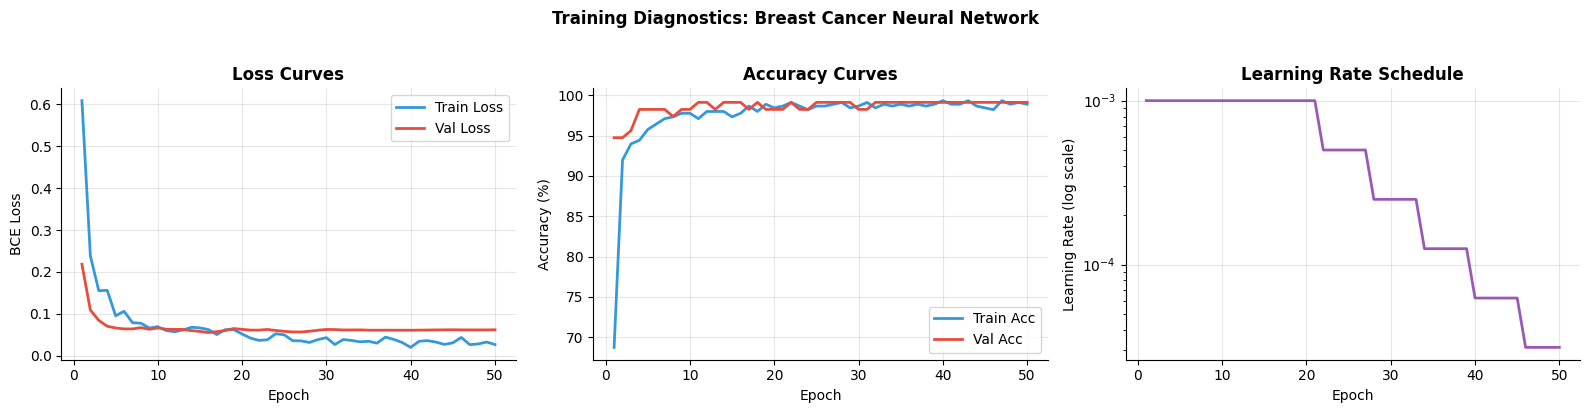


📊 Diagostic curves:
   → If train loss falls but val loss rises: OVERFITTING (network memorizing training data)
   → If both losses fall together: GOOD (network is generalizing to new data)
   → If loss barely decreases: try removing normalization (Cell 3 Exercise 2)


In [10]:
# ============================================================
# CELL 5: TRAINING LOOP & DIAGNOSTIC ARTIFACTS
# ============================================================

# --- Hyperparameters ---
LEARNING_RATE = 1e-3   # Step size for gradient descent
N_EPOCHS      = 50     # Number of complete passes through the training data
LOG_EVERY     = 5      # Print metrics every N epochs
THRESHOLD     = 0.5    # Probability threshold for Malignant classification

# --- Loss Function & Optimizer ---
# BCELoss: Binary Cross-Entropy. Standard for binary classification with Sigmoid output.
# PyTorch Note: Use BCELoss with Sigmoid in model, OR BCEWithLogitsLoss without Sigmoid
# (numerically more stable). We use BCELoss here for pedagogical clarity.
criterion = nn.BCELoss()

# Adam: Adaptive Moment Estimation.
# Maintains per-parameter running averages of gradients AND squared gradients.
# This makes it self-tuning: fast parameters slow down, slow ones speed up.
# weight_decay=1e-4: L2 regularization — adds ||w||² penalty to loss,
# preventing weights from growing too large (another overfitting guard).
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# --- Learning Rate Scheduler ---
# ReduceLROnPlateau: If validation loss doesn't improve for 'patience' epochs,
# reduce learning rate by 'factor'. Like backing off when you stop making progress.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# --- Storage for Training History ---
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : [],
    'lr'        : []
}

# --- Disable forward pass print statements ---
# The shape-printing in forward() was for Cell 4 inspection only.
# We need to monkey-patch the forward method to remove prints for training.
# Clean way: redefine forward without prints for production training.
class CancerClassifierProduction(nn.Module):
    """Same architecture as CancerClassifier but without debug print statements."""
    def __init__(self, input_dim=30, dropout_rate=0.3):
        super().__init__()
        self.fc1     = nn.Linear(input_dim, 128)
        self.fc2     = nn.Linear(128, 64)
        self.fc3     = nn.Linear(64, 32)
        self.fc4     = nn.Linear(32, 1)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=dropout_rate)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.relu(self.fc3(x))
        x = self.sigmoid(self.fc4(x))
        return x

# Re-instantiate clean model
torch.manual_seed(SEED)  # Reset seed for reproducible weight init
model = CancerClassifierProduction(input_dim=30, dropout_rate=0.3).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# --- Helper: Compute Loss & Accuracy on a DataLoader ---
def evaluate(model, loader, criterion, device):
    """
    Runs the model in eval mode over an entire DataLoader.
    Returns mean loss and accuracy across all batches.
    
    model.eval(): Disables Dropout (all neurons active for inference).
    torch.no_grad(): Disables gradient computation — saves memory and compute.
                     We don't need gradients for evaluation, only for training.
    """
    model.eval()  # CRITICAL: disables Dropout
    total_loss, total_correct, total_samples = 0.0, 0, 0
    
    with torch.no_grad():  # No gradient tracking needed here
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            predictions = model(X_batch)           # Forward pass
            loss        = criterion(predictions, y_batch)
            
            # Convert probabilities to class labels using threshold
            pred_labels = (predictions >= THRESHOLD).float()
            correct     = (pred_labels == y_batch).sum().item()
            
            total_loss    += loss.item() * X_batch.size(0)  # Weight by batch size
            total_correct += correct
            total_samples += X_batch.size(0)
    
    return total_loss / total_samples, total_correct / total_samples


# ============================================================
# THE MAIN TRAINING LOOP
# ============================================================
print("=" * 65)
print(" TRAINING: BREAST CANCER NEURAL NETWORK")
print("=" * 65)
print(f"  Architecture : 30 → 128 → 64 → 32 → 1")
print(f"  Loss         : Binary Cross-Entropy")
print(f"  Optimizer    : Adam (lr={LEARNING_RATE}, weight_decay=1e-4)")
print(f"  Epochs       : {N_EPOCHS}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Device       : {DEVICE}")
print("=" * 65)
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8}")
print("-" * 65)

best_val_loss = float('inf')
best_model_path = f'{DRIVE_PATH}best_cancer_model.pt'

for epoch in range(1, N_EPOCHS + 1):
    
    # ---- TRAINING PHASE ----
    model.train()  # Enables Dropout for training
    epoch_loss, epoch_correct, epoch_samples = 0.0, 0, 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        
        # STEP 1: Zero gradients
        # WHY: PyTorch accumulates gradients. Without zeroing,
        # batch N's gradients add to batch N-1's — wrong update direction.
        optimizer.zero_grad()
        
        # STEP 2: Forward pass
        # Executes the computation graph: input → layers → output
        # Records all operations for automatic differentiation
        predictions = model(X_batch)
        
        # STEP 3: Compute loss
        # Scalar: how wrong is the network on this batch?
        loss = criterion(predictions, y_batch)
        
        # STEP 4: Backpropagation
        # Traverses computation graph backwards, computing ∂L/∂w for all w
        # After this: every parameter has a .grad tensor
        loss.backward()
        
        # Gradient Clipping: cap gradient norm at 1.0
        # Prevents 'exploding gradients' — runaway weight updates
        # Like a voltage regulator in an electrical circuit
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # STEP 5: Parameter update
        # w = w - lr * ∂L/∂w  (for Adam: with adaptive scaling)
        optimizer.step()
        
        # Track metrics
        epoch_loss    += loss.item() * X_batch.size(0)
        pred_labels    = (predictions >= THRESHOLD).float()
        epoch_correct += (pred_labels == y_batch).sum().item()
        epoch_samples += X_batch.size(0)
    
    train_loss = epoch_loss    / epoch_samples
    train_acc  = epoch_correct / epoch_samples
    
    # ---- VALIDATION PHASE ----
    val_loss, val_acc = evaluate(model, test_loader, criterion, DEVICE)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history for plots
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    # Save best model checkpoint to Drive
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
    
    # Log every LOG_EVERY epochs
    if epoch % LOG_EVERY == 0 or epoch == 1:
        print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc*100:>8.2f}% | "
              f"{val_loss:>8.4f} | {val_acc*100:>6.2f}% | {current_lr:.2e}")

print("-" * 65)
print(f"\n✅ Training complete. Best validation loss: {best_val_loss:.4f}")
print(f"   Best model saved to: {best_model_path}")

# --- Plot Training Curves ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_range = range(1, N_EPOCHS + 1)

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='#3498db', lw=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='#e74c3c', lw=2)
axes[0].set_title('Loss Curves', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Accuracy curves
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train Acc', color='#3498db', lw=2)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val Acc',   color='#e74c3c', lw=2)
axes[1].set_title('Accuracy Curves', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

# Learning rate schedule
axes[2].semilogy(epochs_range, history['lr'], color='#9b59b6', lw=2)
axes[2].set_title('Learning Rate Schedule', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate (log scale)')
axes[2].grid(alpha=0.3)
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Training Diagnostics: Breast Cancer Neural Network', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}03_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Diagostic curves:")
print("   → If train loss falls but val loss rises: OVERFITTING (network memorizing training data)")
print("   → If both losses fall together: GOOD (network is generalizing to new data)")
print("   → If loss barely decreases: try removing normalization (Cell 3 Exercise 2)")


---
# Cell 6: The Deliverable — Diagnostic Gene-Mass Classification Report

## 🔬 What This Simulates

In a clinical setting, a pathologist receives a cell sample from a fine-needle aspiration biopsy. Computational image analysis measures the nuclear geometry. Our model then produces a **malignancy probability** — a second opinion that can flag high-risk cases for expedited review.

This cell simulates that pipeline: we will pass five mock patients' cellular geometry through the trained network and produce a formatted clinical report.

## 📐 What We Are Measuring

Our 5 mock patients span the full diagnostic spectrum:
1. **Classic Benign**: Small, smooth, regular nuclei — textbook healthy cell geometry
2. **Borderline**: Moderate size, slightly irregular — the hard cases that challenge pathologists
3. **Classic Malignant**: Large, jagged, concave nuclei — clear morphological disruption
4. **Extreme Malignant**: Maximum disruption across all features — aggressive cancer signature
5. **Ambiguous**: Mixed signals — where the model must weigh competing geometric evidence

## 📐 Interpreting the Output

The model output is a probability P(malignant | geometry):
- **> 0.7**: High malignancy confidence → flag for immediate review
- **0.4 – 0.7**: Borderline → recommend repeat biopsy or specialist review
- **< 0.4**: Low malignancy risk → standard monitoring


✅ Best model checkpoint loaded for inference.


╔═══════════════════════════════════════════════════════════════════╗
║      DIAGNOSTIC GENE-MASS CELLULAR CLASSIFICATION REPORT       ║
║          Neural Network Pathology Assist System v1.0           ║
╠═══════════════════════════════════════════════════════════════════╣
║  Model      : CancerClassifier (30→128→64→32→1 + Sigmoid)     ║
║  Dataset    : UCI Breast Cancer Wisconsin (Diagnostic)         ║
║  Threshold  : P > 0.70 → HIGH RISK  |  P < 0.40 → LOW RISK   ║
╠═══════════════════════════════════════════════════════════════════╣
  SAMPLE ID                              P(Malign)        RISK            CALL
─────────────────────────────────────────────────────────────────────
  Patient A — Classic Benign                0.0000       🟢 LOW          BENIGN
  Patient B — Borderline                    0.0173       🟢 LOW          BENIGN
  Patient C — Classic Malignant             1.0000      🔴 HIGH       MALIGNANT
  Patient D — Extreme Ma

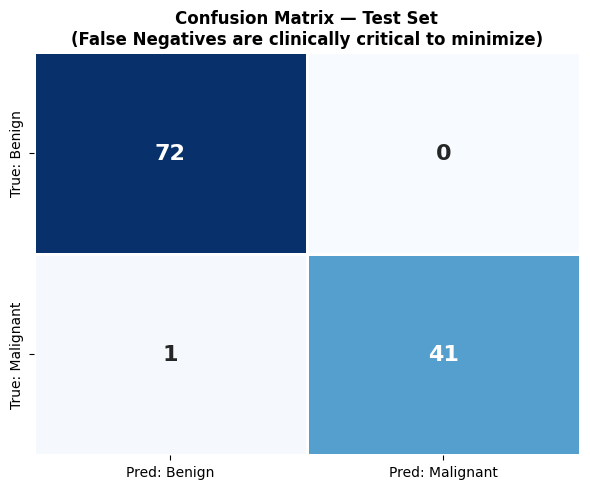


💡 KEY CLINICAL METRICS:
   RECALL for Malignant = True Positive Rate
   → Missing a malignant case (False Negative) is CATASTROPHIC in medicine
   → In medical AI, we optimize RECALL over Precision for the positive class
   → Adjust THRESHOLD downward (e.g. 0.3) to catch more malignant cases at cost of false alarms


In [11]:
# ============================================================
# CELL 6: DIAGNOSTIC GENE-MASS CLASSIFICATION REPORT
# ============================================================

# --- Load best saved model ---
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()  # CRITICAL: disable dropout for inference
print("✅ Best model checkpoint loaded for inference.")

# --- Define Mock Patient Profiles ---
# Each row = one patient's 30 nuclear geometry features
# Features (in order): mean radius, mean texture, mean perimeter, mean area,
#   mean smoothness, mean compactness, mean concavity, mean concave points,
#   mean symmetry, mean fractal dimension,
#   radius SE, texture SE, perimeter SE, area SE, smoothness SE,
#   compactness SE, concavity SE, concave points SE, symmetry SE, fractal dimension SE,
#   worst radius, worst texture, worst perimeter, worst area, worst smoothness,
#   worst compactness, worst concavity, worst concave points, worst symmetry, worst fractal dimension

# These are constructed to represent clinically distinct cases.
# All values are in raw (un-normalized) measurement units — we'll normalize before inference.

mock_patients = {
    'Patient A — Classic Benign': [
        # Small, smooth, regular nuclei — low risk profile
        10.5, 12.0, 67.0, 340.0, 0.085, 0.055, 0.015, 0.010, 0.170, 0.058,
        0.22, 0.90, 1.50, 17.0, 0.006, 0.012, 0.015, 0.005, 0.020, 0.003,
        11.5, 15.0, 73.0, 400.0, 0.100, 0.085, 0.045, 0.020, 0.210, 0.065
    ],
    'Patient B — Borderline': [
        # Moderate values — the diagnostically ambiguous middle ground
        13.5, 18.0, 87.0, 565.0, 0.100, 0.090, 0.065, 0.040, 0.185, 0.062,
        0.35, 1.20, 2.40, 30.0, 0.007, 0.022, 0.035, 0.012, 0.025, 0.004,
        15.5, 24.0, 100.0, 710.0, 0.130, 0.150, 0.130, 0.080, 0.260, 0.075
    ],
    'Patient C — Classic Malignant': [
        # Large, irregular, high concavity — classic cancer morphology
        18.0, 25.0, 120.0, 1010.0, 0.118, 0.165, 0.195, 0.115, 0.220, 0.072,
        0.65, 2.10, 4.50, 65.0, 0.010, 0.040, 0.060, 0.020, 0.040, 0.007,
        22.0, 35.0, 150.0, 1500.0, 0.165, 0.280, 0.350, 0.180, 0.310, 0.095
    ],
    'Patient D — Extreme Malignant': [
        # Maximum morphological disruption — aggressive case
        24.0, 35.0, 165.0, 1800.0, 0.145, 0.250, 0.310, 0.175, 0.270, 0.090,
        1.10, 3.50, 8.00, 120.0, 0.015, 0.065, 0.090, 0.030, 0.060, 0.010,
        28.0, 45.0, 195.0, 2400.0, 0.210, 0.420, 0.520, 0.260, 0.420, 0.125
    ],
    'Patient E — Ambiguous Signals': [
        # Conflicting features: large size but smooth surface — network must weigh evidence
        17.0, 15.0, 112.0, 895.0, 0.082, 0.075, 0.110, 0.070, 0.162, 0.055,
        0.42, 1.00, 3.20, 42.0, 0.005, 0.018, 0.040, 0.015, 0.022, 0.004,
        20.0, 20.0, 135.0, 1200.0, 0.110, 0.130, 0.200, 0.110, 0.240, 0.075
    ]
}

# --- Normalize Using Training Set Statistics ---
# EXACTLY the same normalization as Cell 3 — use the SAME mu and sigma
# computed from the training set. This is the production inference contract.
patient_names   = list(mock_patients.keys())
patient_vectors = np.array(list(mock_patients.values()), dtype=np.float64)  # shape: (5, 30)
patient_vectors_norm = (patient_vectors - mu) / (sigma + 1e-8)              # Z-score normalize

# Convert to tensor
patient_tensor = torch.tensor(patient_vectors_norm, dtype=torch.float32).to(DEVICE)  # shape: (5, 30)

# --- Run Inference ---
with torch.no_grad():
    probabilities = model(patient_tensor).squeeze().cpu().numpy()  # shape: (5,)

# --- Generate Formatted Diagnostic Report ---
print("\n")
print("╔" + "═" * 67 + "╗")
print("║      DIAGNOSTIC GENE-MASS CELLULAR CLASSIFICATION REPORT       ║")
print("║          Neural Network Pathology Assist System v1.0           ║")
print("╠" + "═" * 67 + "╣")
print(f"║  Model      : CancerClassifier (30→128→64→32→1 + Sigmoid)     ║")
print(f"║  Dataset    : UCI Breast Cancer Wisconsin (Diagnostic)         ║")
print(f"║  Threshold  : P > 0.70 → HIGH RISK  |  P < 0.40 → LOW RISK   ║")
print("╠" + "═" * 67 + "╣")
print(f"  {'SAMPLE ID':<38} {'P(Malign)':>9}  {'RISK':>10}  {'CALL':>14}")
print("─" * 69)

risk_levels = []
for name, prob in zip(patient_names, probabilities):
    if prob >= 0.70:
        risk = "🔴 HIGH"
        call = "MALIGNANT"
    elif prob >= 0.40:
        risk = "🟡 MODERATE"
        call = "BORDERLINE"
    else:
        risk = "🟢 LOW"
        call = "BENIGN"
    risk_levels.append(call)
    print(f"  {name:<38} {prob:>9.4f}  {risk:>10}  {call:>14}")

print("─" * 69)

print("\n  FEATURE CONTRIBUTION ANALYSIS (Top 5 features by weight magnitude)")
print("─" * 69)

# Extract first layer weight magnitudes as a rough feature importance proxy
# (Real importance = SHAP values or integrated gradients, but this is instructive)
with torch.no_grad():
    w1 = model.fc1.weight.cpu().numpy()  # shape: (128, 30)
    feature_importance = np.abs(w1).mean(axis=0)  # shape: (30,)
    top5_idx = np.argsort(feature_importance)[-5:][::-1]

feature_names_list = list(raw.feature_names)
for rank, idx in enumerate(top5_idx, 1):
    bar = "█" * int(feature_importance[idx] / feature_importance.max() * 20)
    print(f"  #{rank}  {feature_names_list[idx]:<30} {bar:<20} {feature_importance[idx]:.4f}")

print("\n╔" + "═" * 67 + "╗")
print("║  ⚠️  CLINICAL DISCLAIMER                                       ║")
print("║  This output is generated by a machine learning model trained  ║")
print("║  on geometric features only. It does NOT replace pathologist   ║")
print("║  review. Use as a screening assist tool only.                  ║")
print("╚" + "═" * 67 + "╝")

# --- Final Test Set Confusion Matrix ---
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds = model(X_batch).squeeze().cpu().numpy()
        all_preds.extend((preds >= THRESHOLD).astype(int))
        all_labels.extend(y_batch.squeeze().numpy().astype(int))

cm = confusion_matrix(all_labels, all_preds)
print("\n\n" + "=" * 55)
print(" TEST SET PERFORMANCE SUMMARY")
print("=" * 55)
print(classification_report(all_labels, all_preds, target_names=['Benign', 'Malignant']))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Benign', 'Pred: Malignant'],
            yticklabels=['True: Benign', 'True: Malignant'],
            linewidths=2, linecolor='white', cbar=False,
            annot_kws={'size': 16, 'weight': 'bold'})
ax.set_title('Confusion Matrix — Test Set\n(False Negatives are clinically critical to minimize)', 
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 KEY CLINICAL METRICS:")
print("   RECALL for Malignant = True Positive Rate")
print("   → Missing a malignant case (False Negative) is CATASTROPHIC in medicine")
print("   → In medical AI, we optimize RECALL over Precision for the positive class")
print("   → Adjust THRESHOLD downward (e.g. 0.3) to catch more malignant cases at cost of false alarms")


---
# Cell 7: Intuition-Building & Code-Breaking Exercises

> *"I hear and I forget. I see and I remember. I do and I understand."* — Confucius

The best way to build deep intuition for neural networks is to **break them deliberately** and observe what happens. Each exercise below targets a specific theoretical concept and gives you a concrete failure mode to look for.

---

## 🔴 Exercise 1: The Tensor Shape Experiment

**Concept:** Understand how batch size affects the tensor shape at every layer in the network, and why the architecture is batch-size agnostic by design.

### What to Modify
In **Cell 3**, change the `BATCH_SIZE` variable:
```python
# Try each of these values:
BATCH_SIZE = 1     # Single-sample inference mode
BATCH_SIZE = 8     # Tiny batch
BATCH_SIZE = 128   # Large batch
BATCH_SIZE = 569   # Entire dataset at once (batch gradient descent)
```

Then re-run the shape trace in **Cell 4** (the `dummy_input` section — change `torch.randn(4, 30)` to match your batch size).

### What to Observe
- The **first dimension** of every tensor in `forward()` should always equal your batch size. The rest of the dimensions (`30 → 128 → 64 → 32 → 1`) should never change. This is the key architectural property: **batch-size independence**.
- With `BATCH_SIZE = 1`: each forward pass processes exactly one patient. The tensor shapes become `[1, 30] → [1, 128] → [1, 64] → [1, 32] → [1, 1]`.
- With `BATCH_SIZE = 569`: you're doing full-batch gradient descent. Train for 50 epochs and compare the smoothness of the loss curve to `BATCH_SIZE = 32`. **Full batch = smoother loss but slower convergence and worse generalization.**

### The Failure Mode to Look For
If you set `BATCH_SIZE = 1` and `drop_last=True`, the DataLoader will drop ALL samples (since every batch has exactly `batch_size` samples = no batch has more than 1 element, none get dropped). Check `len(train_loader)` — it should equal the number of training samples. If it's 0, you've discovered a subtle DataLoader configuration bug.

---

## 🟠 Exercise 2: Auditing Normalization — The Gradient Stall

**Concept:** Empirically demonstrate why Z-score normalization is essential for gradient descent convergence on heterogeneous biological data.

### What to Modify
In **Cell 3**, bypass normalization by replacing the normalized arrays with raw arrays:
```python
# ORIGINAL (correct)
train_dataset = BreastCancerDataset(X_train_norm, y_train)
test_dataset  = BreastCancerDataset(X_test_norm,  y_test)

# MODIFIED (for this exercise — deliberately broken)
train_dataset = BreastCancerDataset(X_train, y_train)  # raw, un-normalized
test_dataset  = BreastCancerDataset(X_test,  y_test)   # raw, un-normalized
```

Then retrain from scratch (re-run Cell 4 and Cell 5).

### What to Observe
- The training loss will be very high initially and **converge slowly or not at all** within 50 epochs.
- The loss curve will be **jagged and erratic** — large oscillations caused by the enormous gradient magnitudes from large-scale features (area: ~1000s vs smoothness: ~0.1).
- In extreme cases, you may see `loss = nan` — a gradient explosion where weights grow to infinity. This is the biological data's heterogeneous scale literally breaking the optimizer.
- Compare the loss at epoch 50 with and without normalization. You should see a significant gap — normalization could be the difference between 95% accuracy and 60% accuracy.

### The Mathematical Explanation
Without normalization, the loss landscape is a **elongated ellipsoid** — gradients along the large-scale axes (area) are enormous, while gradients along small-scale axes (smoothness) are tiny. Gradient descent chases the large gradients, overshoots, and oscillates. With normalization, the landscape is a **round sphere** — gradient steps are proportionally balanced, and descent is smooth and fast.

---

## 🟡 Exercise 3: Tracking Overfitting Boundaries

**Concept:** Witness overfitting in real time by building an excessively large network without regularization, and observe the train/val divergence.

### What to Modify
In **Cell 4**, create a new model class (don't overwrite the original — keep it for comparison):

```python
class OvertfittingModel(nn.Module):
    """Deliberately over-parameterized model for overfitting demonstration."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 1024),   # MASSIVE first layer — way too large
            nn.ReLU(),
            # NO DROPOUT — no regularization
            nn.Linear(1024, 1024), # Equally massive second layer
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

overfit_model = OvertfittingModel().to(DEVICE)
# Count parameters — should be ~1.6 MILLION for 569 training samples
print(sum(p.numel() for p in overfit_model.parameters()))
```

Train this model using the same training loop from Cell 5 for 100 epochs. **Increase `N_EPOCHS = 100`.**

### What to Observe
- By epoch ~15-20: training accuracy reaches ~99%+ but validation accuracy plateaus or **declines**.
- The loss curves will **diverge** — train loss decreasing while val loss starts increasing. This is the signature overfitting graph every ML engineer must recognize.
- The model has ~1.6M parameters but only 455 training samples. It has enough capacity to **memorize every training sample** (including their noise) rather than learning generalizable patterns. It's the equivalent of memorizing a textbook word-for-word instead of understanding the concepts.

### How to Fix It (the Learning)
After seeing overfitting, add these mitigations back one at a time and re-train to see which helps most:
1. Add `nn.Dropout(0.5)` after each hidden layer
2. Add `weight_decay=1e-3` to Adam (stronger L2 regularization)
3. Use `nn.BatchNorm1d(1024)` after each linear layer
4. Simply reduce layer sizes back to `128 → 64 → 32`

**Key insight**: The right model size for a dataset scales with the number of training samples. ~12K parameters for ~455 samples (ratio ~27:1) is reasonable. ~1.6M parameters for ~455 samples (ratio ~3500:1) is catastrophic overfit.

---

## 🟢 Bonus Exercise: Clinical Threshold Engineering

**Concept:** In medicine, the classification threshold matters as much as model accuracy.

In **Cell 6**, change `THRESHOLD = 0.5` to `THRESHOLD = 0.3`.

Observe how the confusion matrix changes:
- **False Negatives (missed cancers)** should decrease — we're catching more malignant cases
- **False Positives (false alarms)** will increase — we're flagging more benign cases as suspicious

This is the **precision-recall tradeoff** — fundamental to medical AI. Ask yourself: *which error is more harmful — missing a cancer, or causing unnecessary anxiety and follow-up procedures?* Different medical contexts have different answers. This is why clinical AI is a multidisciplinary problem, not just a ML optimization problem.

---

## 📚 Suggested Next Steps

Once you're comfortable with this notebook, the natural progression is:

1. **Genomic Data**: Apply this same pipeline to RNA-seq expression data (gene expression matrices) — replace the 30 geometry features with thousands of gene expression values. The architecture scales.

2. **Image-Based Pathology**: The real-world version of this problem uses **Convolutional Neural Networks (CNNs)** on actual microscope slide images — the geometry features we used were extracted by computer vision from those images. Try the **PatchCamelyon** dataset.

3. **Protein Structure Prediction**: The geometry-to-function mapping is also the core of **AlphaFold2** — except the input is amino acid sequences and the output is 3D atomic coordinates. Deep learning + biology at its most profound.

4. **Graph Neural Networks for Drug Discovery**: Molecules are graphs (atoms = nodes, bonds = edges). GNNs learn directly on molecular graph structure to predict drug efficacy — the same "learn from biological geometry" insight, extended to chemistry.

5. **Attention Mechanisms in Genomics**: Transformers (the architecture behind GPT) have been applied to DNA sequences (treating nucleotide bases like tokens) — **Enformer** and **Nucleotide Transformer** are key papers to read.

---

> **Remember**: You are not switching careers from software engineering to biology. You are expanding your toolkit. The systems thinking, debugging discipline, and abstraction skills you built writing code are exactly what separates good ML engineers from great ones. Biology is just a new domain with a 3.8-billion-year codebase to reverse-engineer.
